# 📊 Continuum Model – Post-processing and Analysis

<br>
<img style="float: left; padding-right: 15px; padding-left: 0px;" src="../sources/images/logo_continuum.png" width="260px" align=”left” >

- Load model configuration from a JSON settings file.
- Detect the full simulation period from the model hydrograph.
- Select an analysis period (`date_start`, `date_end`, or full period).
- Extract and plot discharge time series at sections (simulated and observed).
- Compute basic performance metrics (NSE, RMSE, relative bias, KGE).
- Compute and plot Flow Duration Curves (FDCs) with custom axis limits.
- Analyse dam storage time series.
- Work with gridded outputs (Discharge, ET, SM) at hourly/daily scales.
- Make spatial maps (mean/sum/max/min) and domain-mean time series.

Most of the generic technical functions are in `postprocessing_tool.py`.  
The hydrological and plotting logic is kept here for educational purposes.


## 🔧 Preliminary Setup

This section handles the initial configuration, including setting the project file, importing necessary libraries, and preparing the working environment.

#### Specify Configuration File

This cell defines the name of the configuration file to be used for the entire workflow. The configuration file, in this case, contains all the parameters for the project.

In [6]:
# Set the name of the settings file
settings_file = "awash_analysis2.json"

print(f"Using settings file: {settings_file}")

Using settings file: awash_analysis2.json


#### Import Required Libraries

This cell imports all the Python libraries necessary to run the notebook.

In [7]:
import os, json
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from datetime import datetime
from pathlib import Path

from ipywidgets import (
    Dropdown, DatePicker, Checkbox, HBox, VBox,
    SelectMultiple, BoundedFloatText
)

import folium
from folium.plugins import MousePosition
from tqdm.auto import tqdm
import rioxarray as rxr

import postprocessing_tools as ppt

%matplotlib inline

#### Load config and set paths

Import of the configuration files

In [8]:
# Define the project root directory
project_root = str(Path().cwd()).replace('notebook_continuum','')

# Load configuration from the JSON file
with open(os.path.join(project_root, "settings", settings_file), 'r') as f:
    config = json.load(f)
    
print(f"Configuration loaded from settings file: {settings_file}")

# Generate folder tree based on the configuration
path_settings = config['path']

Configuration loaded from settings file: awash_analysis2.json


Setup of the folder environment

In [9]:
# 📥 Build paths for model outputs and inputs (based on JSON config)

# Workdir is the parent folder where 'projects' and 'sources' live
workdir = os.path.join(str(Path().cwd().parent.parent), "workdir")

# Project path: workdir/projects/<project_name_from_json>
project_path = os.path.join(workdir, "projects", config["general"]["project"])

# Path settings from JSON (relative to project_path)
path_settings = config["path"]

# --- Output paths (model_state, model_results, etc.) ---
output_path = {}

# Base folder for this project's model output
output_base = os.path.join(project_path, path_settings["hmc_output"])

output_path["model_state"]             = os.path.join(output_base, "model_state")
output_path["model_state_point"]       = os.path.join(output_base, "model_state", "point")
output_path["model_state_gridded"]     = os.path.join(output_base, "model_state", "gridded")
output_path["model_results"]           = os.path.join(output_base, "model_results")
output_path["model_results_point"]     = os.path.join(output_base, "model_results", "point")
output_path["model_results_gridded"]   = os.path.join(output_base, "model_results", "gridded")
output_path["model_results_time_series"] = os.path.join(
    output_base, "model_results", "time_series"
)

# --- Input paths for static data and forcings ---
input_path = {}

data_base = os.path.join(project_path, path_settings["hmc_data"])

input_path["data_geo_point"]         = os.path.join(data_base, "data_geo", "point")
input_path["data_geo_gridded"]       = os.path.join(data_base, "data_geo", "gridded")
input_path["data_forcing_point"]     = os.path.join(data_base, "data_forcing", "point")
input_path["data_forcing_gridded"]   = os.path.join(data_base, "data_forcing", "input")
input_path["data_forcing_time_series"] = os.path.join(data_base, "data_forcing", "time_series")

# MOWE root: observational datasets (river flow, GIS)
input_path["mowe"] = os.path.join(workdir, "sources", "datasets", "mowe")

print("project_path:", project_path)

project_path: /home/continuumuser/workdir/projects/awash_iwrm


In [10]:
hydro_path = os.path.join(output_path["model_results_time_series"], "hmc.hydrograph.txt")
if not os.path.exists(hydro_path):
    raise FileNotFoundError(f"Hydrograph file not found: {hydro_path}")

hydro_df = pd.read_csv(hydro_path, sep=r"\s+", header=None)
hydro_df.rename(columns={0: "time"}, inplace=True)
hydro_df["time"] = pd.to_datetime(hydro_df["time"], format="%Y%m%d%H%M")

start_global = hydro_df["time"].min()
end_global   = hydro_df["time"].max()

print("Hydrograph path:", hydro_path)
print("Full simulation period:", start_global, "→", end_global)

Hydrograph path: /home/continuumuser/workdir/projects/awash_iwrm/continuum/long_run2/model_results/time_series/hmc.hydrograph.txt
Full simulation period: 2001-06-05 00:00:00 → 2001-07-18 14:00:00


In [11]:
analysis_start = "2001-06-22 00:00:00"
analysis_end = "2001-08-22 20:00:00"

In [12]:
# 📥 Load info_section
domain = config['general']["domain"]
info_section_path = os.path.join(input_path["data_geo_point"], f"{domain}.info_section.txt")

if not os.path.exists(info_section_path):
    raise FileNotFoundError(info_section_path)

sections = []
with open(info_section_path, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            sections.append(line)
section_list = [s.split(maxsplit=3)[-1] for s in sections]

print("info_section:", info_section_path)
print("Number of model sections:", len(sections))

info_section: /home/continuumuser/workdir/projects/awash_iwrm/continuum/data_geo/point/awash.info_section.txt
Number of model sections: 47


In [13]:
shp_path = os.path.join(input_path["mowe"], f"GIS/stations/{domain}_river_flow.shp")

if not os.path.exists(shp_path):
    raise FileNotFoundError(shp_path)

stations_gdf = gpd.read_file(shp_path)
print("info_section:", shp_path)
print("Number of mowe sections with data:", len(stations_gdf))

info_section: /home/continuumuser/workdir/sources/datasets/mowe/GIS/stations/awash_river_flow.shp
Number of mowe sections with data: 46


In [14]:
# 🧩 Assign column names in hydro_df based on sections_list
col_map = {i + 1: name for i, name in enumerate(section_list)}
new_cols = ["time"] + [col_map.get(i, f"sec_{i}") for i in range(1, hydro_df.shape[1])]
hydro_df.columns = new_cols

hydro_df

,time,Awash_nr_Bello,Awash_nr_m_kunture,Awash_hombole,Awash_wonji,Awash_below_koka,Keleta_Sire,Holota_Holota,Awash_metehara,Awash_7kilo,...,Kasem_Awara_melka,Arba_bomsa,Muticha_dslegadadi,Litle_Akaki,Kasem_Beke,Great_Akaki,Teji_Asgori,Berga_Addisalem,Awash_Dubti,Tendaho
0,2001-06-05 00:00:00,0.00,0.00,0.00,0.00,6.18,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.19,0.00,0.00,0.00,0.00,0.00,7.52
1,2001-06-05 01:00:00,0.00,0.00,0.00,0.00,18.27,0.00,0.00,0.00,0.00,...,0.03,0.00,0.00,1.99,0.00,0.00,0.00,0.00,0.00,32.09
2,2001-06-05 02:00:00,0.00,0.00,0.00,0.00,20.21,0.00,0.00,0.00,0.00,...,1.49,0.00,0.00,2.19,0.00,0.00,0.00,0.00,0.00,37.56
3,2001-06-05 03:00:00,0.00,0.00,0.00,0.36,20.37,0.00,0.00,0.00,0.00,...,2.51,0.00,0.00,2.17,0.00,0.00,0.00,0.00,0.00,37.75
4,2001-06-05 04:00:00,0.00,0.00,0.00,5.12,20.38,0.00,0.00,0.00,0.00,...,2.57,0.00,0.01,2.14,0.00,0.00,0.00,0.00,0.00,37.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,2001-07-18 10:00:00,230.33,372.09,646.04,734.62,758.23,8.19,20.99,695.75,772.90,...,177.83,1.13,36.12,12.13,4.67,76.66,31.51,34.18,1113.09,1089.66
1043,2001-07-18 11:00:00,223.83,358.40,631.21,768.22,783.80,8.37,22.56,694.25,769.04,...,174.08,1.06,35.30,12.16,4.79,75.09,30.62,35.02,1108.95,1088.07
1044,2001-07-18 12:00:00,219.89,349.60,613.36,790.97,792.88,8.01,32.20,703.37,765.92,...,169.21,1.03,37.19,14.62,5.93,75.61,31.09,42.37,1105.36,1085.04
1045,2001-07-18 13:00:00,222.44,346.25,601.31,796.88,786.90,8.62,37.40,727.63,758.24,...,163.93,1.35,40.51,13.16,5.76,79.21,32.06,51.32,1102.86,1086.92


## 2. Select analysis period

All plots and statistics in this notebook use a **single analysis period**:

- performance metrics and hydrographs,
- Flow Duration Curves (FDC),
- dam storage time series,
- gridded fields and spatial maps.

You control this window by editing the `analysis_start` and `analysis_end` variables
in the cell above.  

- If both are set to `None`, the **full simulation period** (from the hydrograph) is used.  
- If one of them is `None`, it is replaced by the global start/end date.  
- If `analysis_end` is earlier than `analysis_start`, an error is raised.

Any time you change the analysis period, re‑run this section (and the following ones)
to update the plots and indicators.


In [15]:
def get_analysis_period():
    """Return (start, end) for the current analysis period.

    The user sets `analysis_start` and `analysis_end` manually in the cell above.
    - If both are None  -> use full simulation period
    - If one is None    -> replace it with the global start/end
    - Otherwise         -> use the two values as bounds
    """    
    if analysis_start is None and analysis_end is None:
        start, end = start_global, end_global
    else:
        start = pd.to_datetime(analysis_start) if analysis_start is not None else start_global
        end   = pd.to_datetime(analysis_end)   if analysis_end   is not None else end_global
        if end < start:
            raise ValueError("End date earlier than start date")
    return start, end


def restrict_current(df, time_col="time"):
    """Restrict a DataFrame to the current analysis period."""
    start, end = get_analysis_period()
    mask = (df[time_col] >= start) & (df[time_col] <= end)
    return df.loc[mask].copy()


analysis_start_dt, analysis_end_dt = get_analysis_period()
print("Current analysis period:", analysis_start_dt, "→", analysis_end_dt)


Current analysis period: 2001-06-22 00:00:00 → 2001-08-22 20:00:00


## 3. Discharge at sections (simulated vs observed)

In this section we:
1. Show all gauging sections on an interactive **OpenStreetMap** basemap.  
2. Read the section name directly from the map (popup/tooltip).  
3. Use a dropdown to extract and plot:
   - the **simulated** discharge from the model hydrograph  
   - the **observed** discharge from MOWE (when available)

All subsequent time-series analyses are restricted to the selected analysis period.


In [16]:
# 🗺️ Map of stations (sections) on OSM

def make_sections_map(stations_gdf):
    """Plot all gauging stations on an OpenStreetMap basemap.

    The station name is taken from the 'Name' column of the shapefile.
    """
    gdf = stations_gdf.to_crs(epsg=4326)
    center = gdf.geometry.unary_union.centroid

    m = folium.Map(
        location=[center.y, center.x],
        zoom_start=7,
        tiles="OpenStreetMap"
    )

    for _, row in gdf.iterrows():
        # In this shapefile the column with the station name is 'Name'
        name = row["Name"]
        folium.CircleMarker(
            location=(row.geometry.y, row.geometry.x),
            radius=4,
            popup=str(name),
            tooltip=str(name)
        ).add_to(m)

    MousePosition().add_to(m)
    return m

make_sections_map(stations_gdf)


/tmp/ipykernel_15472/805475296.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.unary_union.centroid


In [17]:
# 🎛️ Section selector

section_dropdown = Dropdown(
    options=section_list,
    description="Section:",
    value=section_list[0] if section_list else None
)
display(section_dropdown)


Dropdown(description='Section:', options=('Awash_nr_Bello', 'Awash_nr_m_kunture', 'Awash_hombole', 'Awash_wonj…

In [19]:
section_name = section_dropdown.value

print(f"Selected section: {section_name}")

# --- 2. Check that the simulated series exists ---
if section_name not in hydro_df.columns:
    print(f"❌ Section '{section_name}' not found in hydrograph.")
    sim_df = None
    obs_df = None
else:
    # --- 3. Extract simulated discharge ---
    sim_df = hydro_df[["time", section_name]].copy()
    sim_df.rename(columns={section_name: "sim"}, inplace=True)
    sim_df = restrict_current(sim_df, "time")

    print("✅ Simulated data extracted:")
    display(sim_df.head())

    # --- 4. Build expected observed file path ---
    obs_path = os.path.join(
        input_path["mowe"],
        "series",
        "river_flow",
        domain,
        f"{section_name}.csv"
    )

    print(f"Looking for observed file: {obs_path}")

    # --- 5. Load observed discharge if file exists ---
    if os.path.exists(obs_path):
        obs_raw = pd.read_csv(obs_path, header=None)

        # Convert columns
        obs_raw[0] = pd.to_datetime(obs_raw[0], format="%d/%m/%Y")
        obs_raw.rename(columns={0: "time", 1: "obs"}, inplace=True)

        # Keep only needed columns and restrict period
        obs_df = obs_raw[["time", "obs"]]
        obs_df = restrict_current(obs_df, "time")

        if obs_df.empty:
            print("⚠️ Observed file exists but has NO data in the selected period.")
        else:
            print("✅ Observed data loaded:")
            display(obs_df.head())

    else:
        print("⚠️ No observed file found for this section.")
        obs_df = None

Selected section: Awash_nr_m_kunture
✅ Simulated data extracted:


,time,sim
408,2001-06-22 00:00:00,130.01
409,2001-06-22 01:00:00,133.57
410,2001-06-22 02:00:00,138.26
411,2001-06-22 03:00:00,142.83
412,2001-06-22 04:00:00,146.06


Looking for observed file: /home/continuumuser/workdir/sources/datasets/mowe/series/river_flow/awash/Awash_nr_m_kunture.csv
✅ Observed data loaded:


,time,obs
4190,2001-06-22,17.001
4191,2001-06-23,26.330
4192,2001-06-24,47.550
4193,2001-06-25,44.216
4194,2001-06-26,40.747


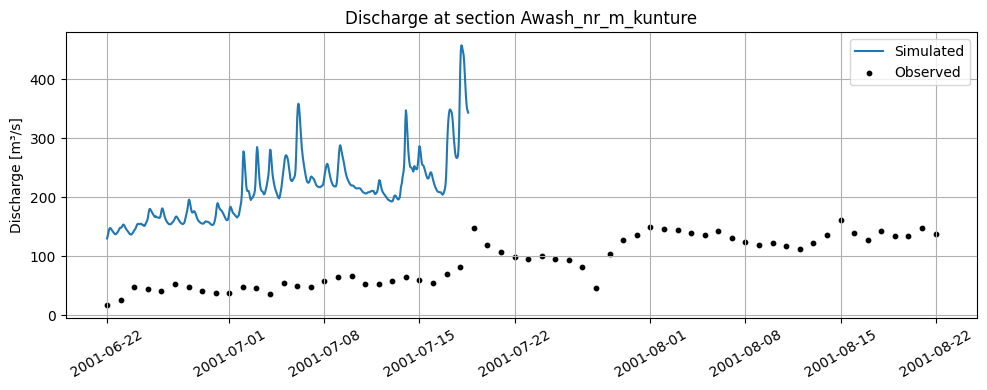

In [22]:
# Check if simulated data is available
if sim_df is None:
    print("Cannot plot because no simulated data was loaded.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))

    # Simulated discharge
    ax.plot(sim_df["time"], sim_df["sim"], label="Simulated", linewidth=1.5)

    # Observed discharge, if available
    if obs_df is not None and not obs_df.empty:
        ax.scatter(obs_df["time"], obs_df["obs"], s=10, color="black", label="Observed")

    ax.set_title(f"Discharge at section {section_name}")
    ax.set_ylabel("Discharge [m³/s]")
    ax.grid(True)
    ax.legend()
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.show()


### 3.1 Performance metrics (NSE, RMSE, bias, KGE)

In [23]:
section_name = section_dropdown.value
print(f"Computing metrics for section: {section_name}")

# 1. Check that we have usable data
if ("sim_df" not in globals()) or ("obs_df" not in globals()):
    print("❌ sim_df and obs_df are not defined. Run the time-series extraction cell first.")
    metrics_df = None

elif sim_df is None or obs_df is None or obs_df.empty:
    print("❌ Cannot compute metrics: no observed data available.")
    metrics_df = None

else:
    # 2. Align simulated and observed on 'time'
    df_merged = pd.merge(
        sim_df[["time", "sim"]],
        obs_df[["time", "obs"]],
        on="time",
        how="inner"
    )
    print(f"Points after aligning on time: {len(df_merged)}")

    # 3. Remove rows with NaN in sim or obs
    df_clean = df_merged.dropna(subset=["sim", "obs"])
    n_removed = len(df_merged) - len(df_clean)
    if n_removed > 0:
        print(f"⚠️ Removed {n_removed} rows with NaNs.")
    else:
        print("✅ No NaNs in sim/obs.")

    # If too few points, return NaNs
    if len(df_clean) < 2:
        print("❌ Not enough valid points to compute metrics.")
        metrics = {
            "NSE": np.nan,
            "RMSE": np.nan,
            "Bias_rel": np.nan,
            "KGE": np.nan,
        }
    else:
        # 4. Extract numpy arrays
        s = df_clean["sim"].to_numpy()
        o = df_clean["obs"].to_numpy()

        # --- RMSE ---
        sq_diff = (s - o) ** 2
        mse = np.mean(sq_diff)
        rmse = np.sqrt(mse)

        # --- Means ---
        mean_o = np.mean(o)
        mean_s = np.mean(s)

        # --- Relative Bias ---
        if mean_o != 0:
            bias_rel = (mean_s - mean_o) / mean_o
        else:
            bias_rel = np.nan

        # --- NSE (Nash-Sutcliffe Efficiency) ---
        denom = np.sum((o - mean_o) ** 2)
        if denom > 0:
            nse = 1.0 - np.sum((s - o) ** 2) / denom
        else:
            nse = np.nan

        # --- Correlation r ---
        r = df_clean["sim"].corr(df_clean["obs"]) if len(df_clean) > 1 else np.nan

        # --- Standard deviations ---
        std_s = np.std(s, ddof=1)
        std_o = np.std(o, ddof=1)

        alpha = std_s / std_o if std_o != 0 else np.nan
        beta  = mean_s / mean_o if mean_o != 0 else np.nan

        # --- KGE (Kling-Gupta Efficiency, 2009) ---
        if np.any(np.isnan([r, alpha, beta])):
            kge = np.nan
        else:
            kge = 1.0 - np.sqrt((r - 1.0) ** 2 +
                                (alpha - 1.0) ** 2 +
                                (beta - 1.0) ** 2)

        metrics = {
            "NSE": float(nse),
            "RMSE": float(rmse),
            "Bias_rel": float(bias_rel),
            "KGE": float(kge),
        }

    # 5. Show metrics as a small table
    metrics_df = pd.DataFrame(metrics, index=[section_name]).T
    display(metrics_df.style.format("{:.3f}"))


Computing metrics for section: Awash_nr_m_kunture
Points after aligning on time: 27
✅ No NaNs in sim/obs.


,Awash_nr_m_kunture
NSE,-193.353
RMSE,185.970
Bias_rel,3.508
KGE,-4.347


### 3.2 Flow Duration Curve (FDC)

This tool builds a **Flow Duration Curve** for the selected river section:

- The curve shows the simulated (and, if available, observed) discharge values
  ranked from highest to lowest.  
- The x‑axis is the **exceedance probability** (% of time a given flow is equalled or exceeded).  
- The y‑axis is the **discharge** (usually on a logarithmic scale).

How to use this widget:

1. Select the desired **section** in the dropdown above.  
2. Optionally adjust the **minimum** and **maximum** discharge values (`Q min (y)` and `Q max (y)`)
   to focus on a specific range of flows.  
3. Run the cell to plot:
   - the **simulated** FDC, always shown, and  
   - the **observed** FDC, if observational data are available for that station.

The FDC is always computed over the **current analysis period** defined in Section 2.


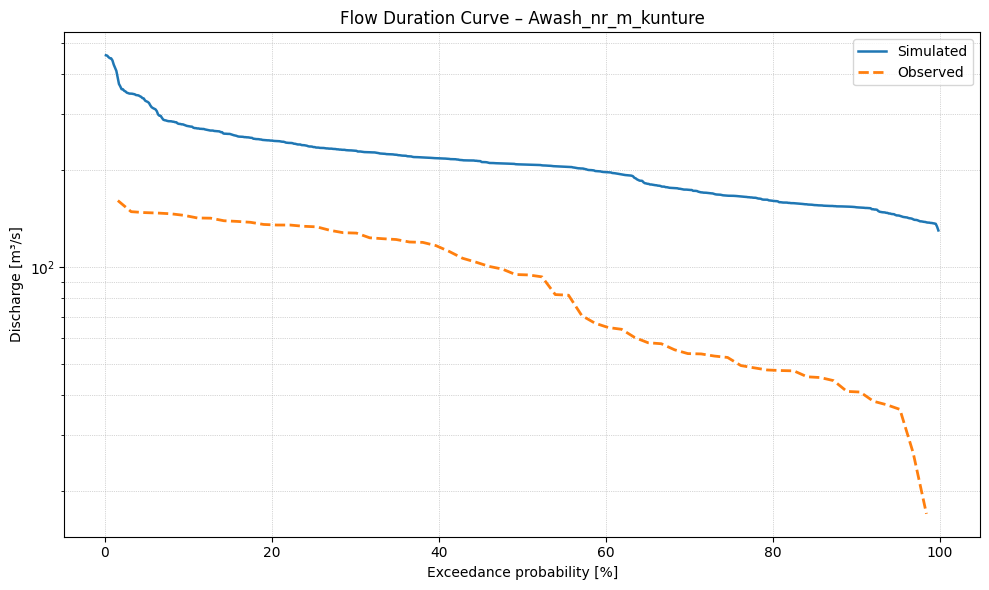

In [24]:
def flow_duration_curve(Q):
    Q_sorted = np.sort(Q)[::-1]   # descending order
    N = len(Q_sorted)
    p = np.arange(1, N+1) / (N + 1) * 100
    return p, Q_sorted

import numpy as np
import matplotlib.pyplot as plt

section_name = section_dropdown.value

# --- 1. Prepare simulated and observed arrays ---
if sim_df is None:
    print("No simulated data.")
else:
    sim_vals = sim_df["sim"].dropna().to_numpy()

if obs_df is not None and not obs_df.empty:
    obs_vals = obs_df["obs"].dropna().to_numpy()
else:
    obs_vals = None


# --- 2. Compute FDC points ---
# Simulated
p_sim, q_sim = flow_duration_curve(sim_vals)

# Observed
if obs_vals is not None:
    p_obs, q_obs = flow_duration_curve(obs_vals)


# --- 3. Plot ---
plt.figure(figsize=(10,6))

plt.plot(p_sim, q_sim, label="Simulated", linewidth=1.8)

if obs_vals is not None:
    plt.plot(p_obs, q_obs, '--', label="Observed", linewidth=2)

plt.yscale('log')
plt.xlabel("Exceedance probability [%]")
plt.ylabel("Discharge [m³/s]")
plt.title(f"Flow Duration Curve – {section_name}")
plt.grid(True, which="both", linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Dam storage (vdam)

In this section we:

- Read the dam metadata file (`*.info_dam.txt`) created in the static data step.  
- Read the corresponding **vdam** time series (`hmc.vdam.txt`) from the model results.  
- Let the user select a dam and visualise the simulated **stored volume** over time,
  restricted to the chosen analysis period.


In [25]:
# 📥 Load dam metadata (info_dam) and vdam time series

# info_dam: text file describing dams in the basin
info_dam_path = os.path.join(
    input_path["data_geo_point"],
    f"{domain}.info_dam.txt"
)

import re
dam_names = []
with open(info_dam_path, "r") as f:
    current = None
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("####"):
            current = None
            continue
        if current is None:
            current = line
            dam_names.append(re.split(r'\s+#', current)[0])
dam_names = dam_names[1:]
print("Dams found:", dam_names)

# vdam: time series of stored volumes in the reservoirs
vdam_path = os.path.join(
    output_path["model_results_time_series"],
    "hmc.vdam.txt"
)

if os.path.exists(vdam_path):
    vdam_df = pd.read_csv(vdam_path, sep=r'\s+', header=None)
    vdam_df.rename(columns={0: "time"}, inplace=True)
    vdam_df["time"] = pd.to_datetime(vdam_df["time"], format="%Y%m%d%H%M")
    print("vdam path:", vdam_path)
else:
    print("WARNING: vdam file not found:", vdam_path)
    vdam_df = None


Dams found: ['Legadadi', 'Gafarsa', 'Koka', 'Kessem', 'Tendaho', 'Dire', 'Aba Samuel']
vdam path: /home/continuumuser/workdir/projects/awash_iwrm/continuum/long_run2/model_results/time_series/hmc.vdam.txt


In [26]:
def make_dams_map(stations_gdf):
    """Plot all gauging stations on an OpenStreetMap basemap.

    The station name is taken from the 'Name' column of the shapefile.
    """
    gdf = stations_gdf.to_crs(epsg=4326)
    center = gdf.geometry.unary_union.centroid

    m = folium.Map(
        location=[center.y, center.x],
        zoom_start=7,
        tiles="OpenStreetMap"
    )

    for _, row in gdf.iterrows():
        # In this shapefile the column with the station name is 'Name'
        name = row["DAM_NAME"]
        folium.CircleMarker(
            location=(row.geometry.y, row.geometry.x),
            radius=4,
            popup=str(name),
            tooltip=str(name)
        ).add_to(m)

    MousePosition().add_to(m)
    return m

dams_shp = os.path.join(project_path, "data", "awash_dams.shp")
dams_gdf = gpd.read_file(dams_shp)
make_dams_map(dams_gdf)

/tmp/ipykernel_15472/3739947397.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = gdf.geometry.unary_union.centroid


In [27]:
# Prepare vdam DataFrame with dam names as column labels

if vdam_df is not None and dam_names:
    col_map_dam = {i + 1: name for i, name in enumerate(dam_names)}
    new_cols = ["time"] + [col_map_dam.get(i, f"dam_{i}") for i in range(1, vdam_df.shape[1])]
    vdam_df.columns = new_cols
    print("vdam columns:", vdam_df.columns)

dam_dropdown = Dropdown(
    options=dam_names,
    description="Dam:",
    value=dam_names[0] if dam_names else None
)
display(dam_dropdown)


vdam columns: Index(['time', 'Legadadi', 'Gafarsa', 'Koka', 'Kessem', 'Tendaho', 'Dire',
       'Aba Samuel'],
      dtype='object')


Dropdown(description='Dam:', options=('Legadadi', 'Gafarsa', 'Koka', 'Kessem', 'Tendaho', 'Dire', 'Aba Samuel'…

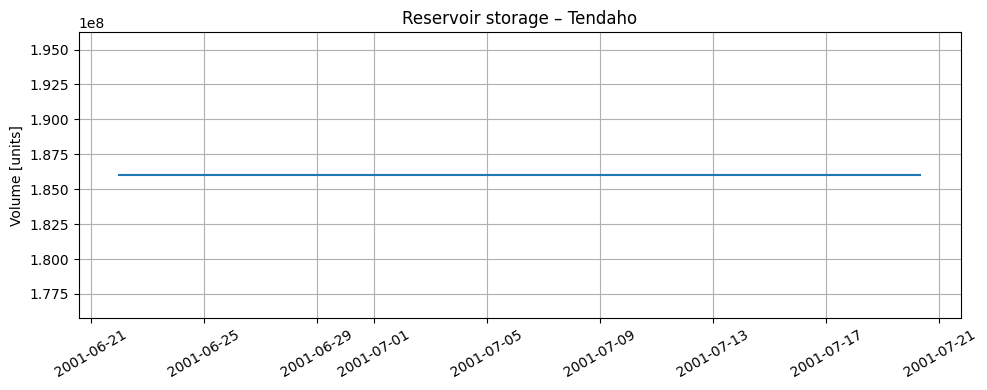

In [28]:
def plot_dam_storage(dam_name):
    """Plot reservoir storage time series for the selected dam."""
    if vdam_df is None:
        print("No vdam data available.")
        return None

    if dam_name not in vdam_df.columns:
        print(f"Dam {dam_name} not in vdam file.")
        return None

    df = vdam_df[["time", dam_name]].copy()
    df.rename(columns={dam_name: "storage"}, inplace=True)
    df = restrict_current(df, "time")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["time"], df["storage"], linewidth=1.5)
    ax.set_title(f"Reservoir storage – {dam_name}")
    ax.set_ylabel("Volume [units]")
    ax.grid(True)
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return df

dam_storage_df = plot_dam_storage(dam_dropdown.value)


## 5. Gridded outputs (Discharge, ET, SM)

Here we work with the **gridded NetCDF outputs** of the model:

- Discover all `hmc.output-grid*.nc.gz` files in the gridded output folder.  
- Let the user choose the variables of interest (`Discharge`, `ET`, `SM`) and the temporal scale
  (`hourly` or `daily`).  
- Load and aggregate the selected variables into `xarray.DataArray` objects stored in the
  dictionary `gridded_data`.

These gridded fields are then used to:
- extract a time series at a specific station (nearest grid cell),  
- compute spatial maps (mean/sum/min/max over the analysis period),  
- compute domain-mean time series.


#### 🔍 Discover gridded output files and inspect the first one

In this step we:

1. Read the user-selected analysis period.
2. Scan the gridded output directory for files matching  
   `hmc.output-grid.*00.nc.gz`.
3. Extract the timestamp from the filename (YYYYMMDDHH).
4. Filter files that fall inside the selected period.
5. Open the *first* gridded file to inspect its internal structure:
   - Which variables it contains
   - Dimensions, coordinates
   - Data types

This allows the user to understand what the model produces before extracting anything.


In [29]:
import os
import re
import gzip
import io
from datetime import datetime
import xarray as xr

# Map logical variable names to NetCDF variable names
NC_VAR_MAP = {
    "Discharge": "Discharge",
    "ET": "ET",
    "SM": "SM",
}

# 1. Read the analysis period from widgets
analysis_start, analysis_end = get_analysis_period()
print("Analysis period:", analysis_start, "→", analysis_end)

# 2. Directory containing the model gridded results
gridded_dir = output_path["model_results_gridded"]
print("Gridded directory:", gridded_dir)

# 3. Scan files inside the directory for valid state-grid outputs
files_with_time = []

for root, _, files in os.walk(gridded_dir):
    for fname in files:
        if not (fname.startswith("hmc.output-grid") and fname.endswith("00.nc.gz")):
            continue

        # extract YYYYMMDDHH from filename
        m = re.search(r"(\d{10})", fname)
        if not m:
            continue

        dt = datetime.strptime(m.group(1), "%Y%m%d%H")

        # filter by analysis period
        if analysis_start and dt < analysis_start:
            continue
        if analysis_end and dt > analysis_end:
            continue

        full_path = os.path.join(root, fname)
        files_with_time.append((full_path, dt))

# sort by time
files_with_time.sort(key=lambda x: x[1])

if not files_with_time:
    raise RuntimeError("No state-grid files found inside selected period.")

print(f"Found {len(files_with_time)} gridded files.")

# 4. Inspect the first available file
first_path, first_dt = files_with_time[0]
print("\nInspecting first file:")
print(" - path:", first_path)
print(" - datetime:", first_dt)

# 5. Decompress the .gz file in memory and open the NetCDF using xarray
with gzip.open(first_path, "rb") as gz:
    raw_bytes = gz.read()

ds_example = xr.open_dataset(io.BytesIO(raw_bytes))

print("\nExample dataset content:")
display(ds_example)

print("\nAvailable variables:")
print(list(ds_example.data_vars))


Analysis period: 2001-06-22 00:00:00 → 2001-08-22 20:00:00
Gridded directory: /home/continuumuser/workdir/projects/awash_iwrm/continuum/long_run2/model_results/gridded
Found 685 gridded files.

Inspecting first file:
 - path: /home/continuumuser/workdir/projects/awash_iwrm/continuum/long_run2/model_results/gridded/2001/06/22/hmc.output-grid.200106220000.nc.gz
 - datetime: 2001-06-22 00:00:00

Example dataset content:


<xarray.Dataset> Size: 12MB
Dimensions:    (south_north: 490, west_east: 594, time: 1)
Coordinates:
  * time       (time) datetime64[ns] 8B 2001-06-22
    Longitude  (south_north, west_east) float32 1MB ...
    Latitude   (south_north, west_east) float32 1MB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    times      |S19 19B ...
    SM         (south_north, west_east) float32 1MB ...
    Discharge  (south_north, west_east) float32 1MB ...
    ET         (south_north, west_east) float32 1MB ...
    REff       (south_north, west_east) float32 1MB ...
    H          (south_north, west_east) float32 1MB ...
    LE         (south_north, west_east) float32 1MB ...
    LST        (south_north, west_east) float32 1MB ...
    VTot       (south_north, west_east) float32 1MB ...
Attributes:
    time_coverage_end:  2001-06-22_00:00:00
    xllcorner:          37.986156
    yllcorner:          7.897662
    xcellsize:          0.008993216
    ycellsize:          0.008993216
    nrows:              490
    ncols:              594


Available variables:
['times', 'SM', 'Discharge', 'ET', 'REff', 'H', 'LE', 'LST', 'VTot']


#### Select a variable and plot it

Here we choose **one variable by simply writing its name in a string**.
No dropdowns are used.

We then:

- Extract the variable from the inspected dataset
- If it is gridded, plot the spatial map for the first timestep
- Optionally display a time-series (spatial average)

This step helps the user understand the nature and scaling of a variable
before processing all files.


Selected variable: ET


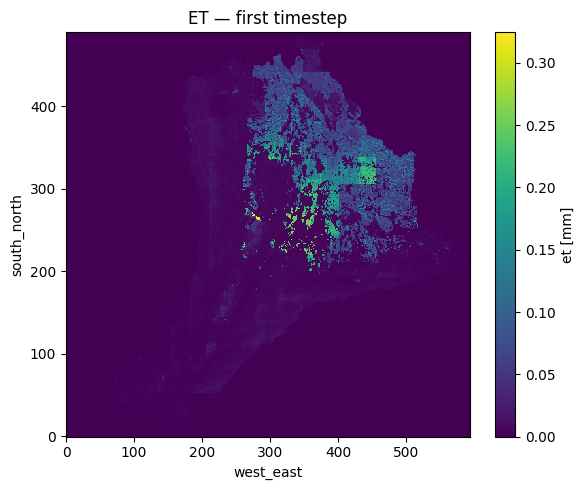

In [30]:
import matplotlib.pyplot as plt

# User chooses the variable name manually
var_name = "ET"   # ← change manually to: "ET", "SM", etc.

print(f"Selected variable: {var_name}")

if var_name not in ds_example:
    raise ValueError(f"Variable '{var_name}' not found in the dataset.")

da = ds_example[var_name]

# identify spatial dims
spatial_dims = [d for d in da.dims if d not in ["time"]]

# --- First-timestep spatial map ---
if "time" in da.dims:
    da0 = da.isel(time=0)
else:
    da0 = da

plt.figure(figsize=(6,5))
da0.plot()
plt.title(f"{var_name} — first timestep")
plt.tight_layout()
plt.show()

# --- Optional: spatially-averaged time series ---
if "time" in da.dims:
    if spatial_dims:
        da_ts = da.mean(dim=spatial_dims)
    else:
        da_ts = da

    plt.figure(figsize=(8,4))
    da_ts.plot()
    plt.title(f"{var_name} — spatial mean time series")
    plt.tight_layout()
    plt.show()


In [31]:
import pandas as pd

variables = ["ET", "SM", "Discharge"]
print("Variables requested:", variables)

rows = []
gridded_store = {var: {} for var in variables}   # <-- NEW: store full maps

print("Reading model output...")

for fpath, dt in files_with_time:
    with gzip.open(fpath, "rb") as gz:
        raw_bytes = gz.read()

    ds = xr.open_dataset(io.BytesIO(raw_bytes))
    row = {"time": dt}

    for logical_name in variables:
        if logical_name not in NC_VAR_MAP:
            continue

        nc_var = NC_VAR_MAP[logical_name]
        if nc_var not in ds:
            continue

        da = ds[nc_var].astype("float32")

        # ignore negative values
        da = da.where(da >= 0)

        # store full map for later spatial plots
        gridded_store[logical_name][dt] = da   # <-- STORE IT

        # spatial mean for dataframe
        spatial_dims = [d for d in da.dims if d not in ["time"]]
        if spatial_dims:
            da_mean = da.mean(dim=spatial_dims)
        else:
            da_mean = da

        if "time" in da_mean.dims and da_mean.sizes["time"] == 1:
            row[logical_name] = float(da_mean.isel(time=0).values)
        else:
            row[logical_name] = float(da_mean.values)

    ds.close()
    rows.append(row)

df_hourly = pd.DataFrame(rows).sort_values("time").set_index("time")

print("\nHourly dataframe:")
display(df_hourly.head())

print("\nStored full grids in memory for fast spatial processing.")
print({k: len(v) for k, v in gridded_store.items()})


Variables requested: ['ET', 'SM', 'Discharge']
Reading model output...

Hourly dataframe:


,ET,SM,Discharge
time,,,
2001-06-22 00:00:00,0.010422,0.569406,2.536777
2001-06-22 01:00:00,0.009821,0.569291,2.535771
2001-06-22 02:00:00,0.009532,0.569162,2.534989
2001-06-22 03:00:00,0.008499,0.569034,2.534565
2001-06-22 04:00:00,0.012733,0.568899,2.534396



Stored full grids in memory for fast spatial processing.
{'ET': 685, 'SM': 685, 'Discharge': 685}


#### ⏱️ Temporal aggregation (hourly or daily)

Depending on the user selection:

- **Hourly** → keep the DataFrame as is  
- **Daily**
- **Monthly**
  - Discharge →  mean  
  - SM →  mean  
  - ET →  sum  

The final result is a clean DataFrame `df_dyn`
with the variables aligned over the selected period.

In [32]:
scale = "monthly"   # "hourly" or "daily" or "monthly"
print("Selected scale:", scale)

if scale == "hourly":
    df_dyn = df_hourly.copy()

else:
    if scale == "daily":
        aggr = "1D"
    elif scale == "monthly":
        aggr = "1M"
    # daily aggregation
    df_daily = pd.DataFrame()

    for var in variables:
        if var not in df_hourly:
            continue

        s = df_hourly[var]

        if var == "ET":
            # cumulative variable: sum per day
            s_agg = s.resample(aggr).sum()
        else:
            # average per day
            s_agg = s.resample(aggr).mean()

        df_daily[var] = s_agg

    df_dyn = df_daily

print("\n✅ Final dynamic dataframe:")
display(df_dyn.head())


Selected scale: monthly

✅ Final dynamic dataframe:


/tmp/ipykernel_15472/2478197655.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_agg = s.resample(aggr).sum()
/tmp/ipykernel_15472/2478197655.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_agg = s.resample(aggr).mean()
/tmp/ipykernel_15472/2478197655.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_agg = s.resample(aggr).mean()


,ET,SM,Discharge
time,,,
2001-06-30,9.865881,0.552938,2.240713
2001-07-31,28.638080,0.516924,2.296439


#### Plot basin-average time series

In this step we plot the time series of **basin-average variables**
stored in the dataframe `df_dyn`.

- `df_dyn` has a time index (hourly or daily, depending on the selected scale).
- Each column corresponds to a basin-average variable (e.g. `ET`, `SM`, `Discharge`).

We:
1. Choose one variable name as a string (e.g. `"Discharge"`).
2. Plot its time series.
3. Optionally, plot multiple variables together for comparison.

Columns available in df_dyn: ['ET', 'SM', 'Discharge']


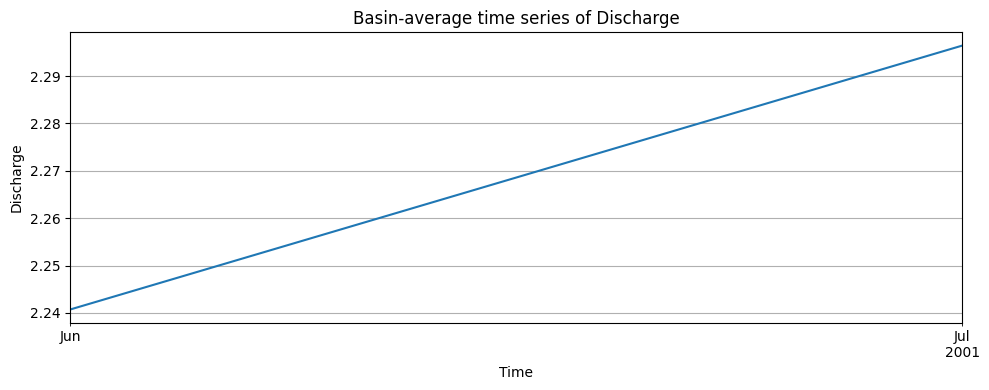

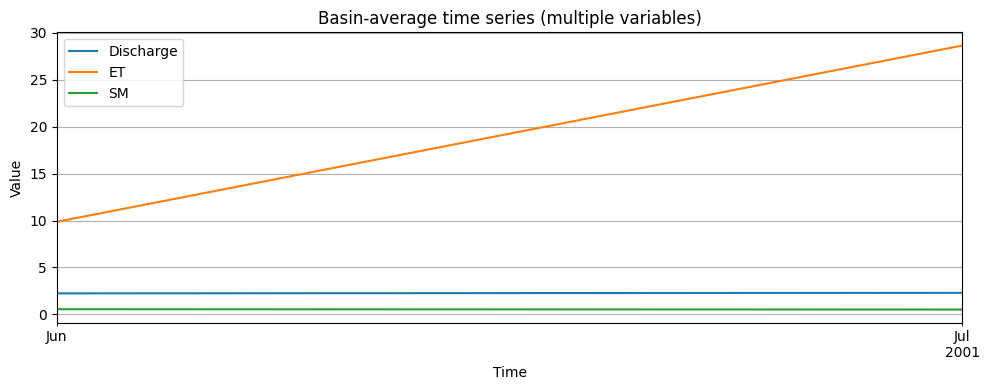

In [33]:
import matplotlib.pyplot as plt

# Check that df_dyn exists
if "df_dyn" not in globals():
    raise RuntimeError("df_dyn is not defined. Run the aggregation cells first.")

print("Columns available in df_dyn:", list(df_dyn.columns))

# --- Choose a single variable to plot ---
var_ts = "Discharge"   # <-- change to "ET" or "SM" as needed

if var_ts not in df_dyn.columns:
    raise ValueError(f"Variable '{var_ts}' not found in df_dyn columns.")

plt.figure(figsize=(10, 4))
df_dyn[var_ts].plot()
plt.title(f"Basin-average time series of {var_ts}")
plt.xlabel("Time")
plt.ylabel(var_ts)
plt.grid(True)
plt.tight_layout()
plt.show()

# --- OPTIONAL: plot multiple variables together ---
vars_multi = ["Discharge", "ET", "SM"]  # edit this list as desired
vars_multi = [v for v in vars_multi if v in df_dyn.columns]

if vars_multi:
    plt.figure(figsize=(10, 4))
    df_dyn[vars_multi].plot(ax=plt.gca())
    plt.title("Basin-average time series (multiple variables)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No variables from vars_multi found in df_dyn.")


#### 🗺️ Spatial aggregation using in-memory grids

Since we stored all gridded fields in memory in `gridded_store`,
we can aggregate them without reading files again.

Rules:
- Discharge, SM → time mean
- ET → time sum

This produces an aggregated spatial map for the selected period.

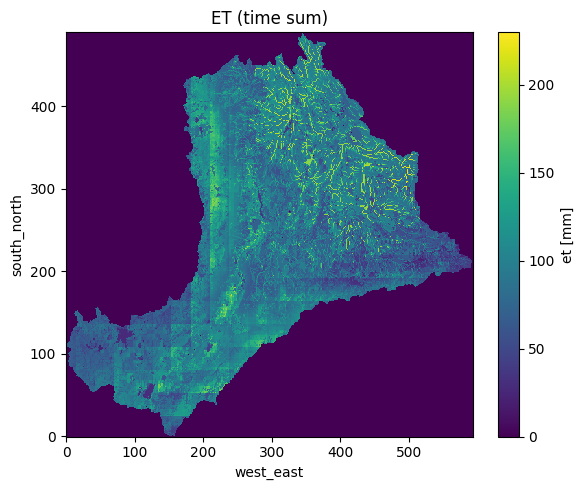

In [35]:
var_map = "ET"   # change to "ET" or "SM"

if var_map not in gridded_store:
    raise ValueError(f"Variable {var_map} not in gridded_store")

# Collect all Da for the variable
list_of_da = []
list_of_times = []

for dt, da in gridded_store[var_map].items():
    if "time" in da.dims:
        da_dt = da
    else:
        da_dt = da.expand_dims(time=[dt])
    list_of_da.append(da_dt)
    list_of_times.append(dt)

# Concatenate in time
da_all = xr.concat(list_of_da, dim="time").sortby("time")

# temporal aggregation
if var_map == "ET":
    da_agg = da_all.sum(dim="time")
    agg_type = "time sum"
else:
    da_agg = da_all.mean(dim="time")
    agg_type = "time mean"

plt.figure(figsize=(6,5))
da_agg.plot()
plt.title(f"{var_map} ({agg_type})")
plt.tight_layout()
plt.show()
